In [2]:
import numpy as np
import random  
import matplotlib.pyplot as plt

from qiskit import transpile
from qiskit.circuit import Parameter,ParameterExpression
from qiskit_algorithms import NumPyMinimumEigensolver
from qiskit.circuit.library import QAOAAnsatz
from qiskit_ibm_runtime import Session, EstimatorV2 as Estimator
from qiskit_ibm_runtime.fake_provider import FakeMumbaiV2
from qiskit.converters import circuit_to_dag, dag_to_circuit
from qiskit_optimization.applications import Knapsack
from qiskit_optimization.algorithms import MinimumEigenOptimizer
from qiskit_optimization.converters import QuadraticProgramToQubo
from qiskit.circuit.library import QAOAAnsatz
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel


import sys
sys.path.append("../")
from clapton.clapton import claptonize
from clapton.circuit_manipulation import transform_to_allowed_gates,qiskit_to_stim, modify_circuit, multi_angle_qaoa_circuit, generate_qiskit_param_map,relax_qaoa_parameters
from testing_scripts.qaoa_utils import evaluate_energy, QAOASolver
from testing_scripts.knapsack_utils import generate_knapsack_instance

import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)

In [3]:
# prob = Knapsack(values=[3, 4, 5, 6, 7,8,9,10,11,12], weights=[2, 3, 4, 5, 6,7,8,9,10,11], max_weight=10)

# Example usage
prob = generate_knapsack_instance(num_items=2,seed=0)

In [4]:
# prob = Knapsack(values=[3, 4, 5, 6, 7,8,9,10,11,12], weights=[2, 3, 4, 5, 6,7,8,9,10,11], max_weight=10)
qp = prob.to_quadratic_program()
print(qp.prettyprint())

Problem name: Knapsack

Maximize
  2*x_0 + 4*x_1

Subject to
  Linear constraints (1)
    4*x_0 + 4*x_1 <= 0  'c0'

  Binary variables (2)
    x_0 x_1



In [5]:
# intermediate QUBO form of the optimization problem
conv = QuadraticProgramToQubo()
qubo = conv.convert(qp)
print(qubo.prettyprint())

Problem name: Knapsack

Minimize
  112*x_0^2 + 224*x_0*x_1 + 112*x_1^2 - 2*x_0 - 4*x_1

Subject to
  No constraints

  Binary variables (2)
    x_0 x_1



In [6]:
# qubit Hamiltonian and offset
op, offset = qubo.to_ising()
print(f"num qubits: {op.num_qubits}, offset: {offset}\n")
print(op)
cost_hamiltonian = op
print(f"Number of terms : {len(cost_hamiltonian)}")

num qubits: 2, offset: 165.0

SparsePauliOp(['IZ', 'ZI', 'ZZ'],
              coeffs=[-111.+0.j, -110.+0.j,   56.+0.j])
Number of terms : 3


In [7]:
reps=2
circuit = QAOAAnsatz(cost_operator=cost_hamiltonian, reps=reps)

In [8]:
knapsack_qaoa = QAOASolver(cost_hamiltonian,circuit,sim_device="CPU")
knapsack_qaoa.prepare_circuit()
knapsack_qaoa.pcirc.num_parameters

10

In [9]:
# Run CAFQA Process
knapsack_qaoa.run_CAFQA(n_gens=1)

STARTING ROUND 0


started GA at id 1 with 8 procs

started GA at id 2 with 8 procs
GA parameters used for this experiment:
  num_generations=0
  num_parents_mating=20
  population_size=100
  num_genes=10
  parent_selection_type=tournament
  keep_parents=-1
  crossover_type=single_point
  mutation_type=adaptive
  crossover_probability=0.9
  mutation_probability=(0.25, 0.01)
  keep_elitism=5
started GA at id None with 8 procs

GA parameters used for this experiment:
  num_generations=0
  num_parents_mating=20
  population_size=100
  num_genes=10
  parent_selection_type=tournament
  keep_parents=-1
  crossover_type=single_point
  mutation_type=adaptive
  crossover_probability=0.9
  mutation_probability=(0.25, 0.01)
  keep_elitism=5

started GA at id 3 with 8 procs

GA parameters used for this experiment:
  num_generations=0
  num_parents_mating=20
  population_size=100
  num_genes=10
  parent_selection_type=tournament
  keep_parents=-1
  crossover_type=single_point
  mutation_type=adapti

In [10]:
knapsack_qaoa.energy_best

np.float64(-165.0)

In [11]:
knapsack_qaoa.evaluate_exact_energy()

Exact Energy from Eigensolver: -165.0


np.float64(-165.0)

In [12]:
cafqa_angles = [param * np.pi/2 for param in knapsack_qaoa.ks_best]

In [13]:
energies = [evaluate_energy(knapsack_qaoa.pcirc, cost_hamiltonian, cafqa_angles) for _ in range(10)]
average_energy = np.mean(energies)
print(f"Average CAFQA Qiskit Energy: {average_energy}")

Average CAFQA Qiskit Energy: -164.99999999999994


In [14]:
# Random Initalization 
random_angles = np.random.random(len(knapsack_qaoa.ks_best))
random_energies = [evaluate_energy(knapsack_qaoa.pcirc, cost_hamiltonian, random_angles) for _ in range(10)]
min_energy = min(random_energies)
print(f"Minimum Energy found with Random initialization over 100 runs: {min_energy}")

Minimum Energy found with Random initialization over 100 runs: 38.252306441210884


In [16]:
cafqa_result,cafqa_iteration_vals = knapsack_qaoa.run_qaoa(cafqa_angles,max_iters=1000)
random_result,random_iteration_vals = knapsack_qaoa.run_qaoa(random_angles,max_iters=1000)

Exact Energy from Eigensolver: -165.0


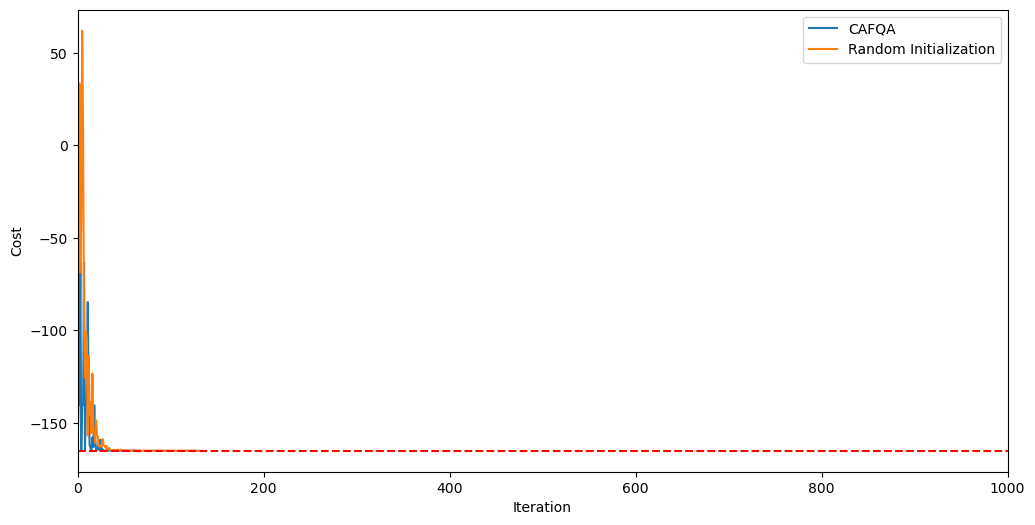

In [17]:
plt.figure(figsize=(12, 6))
plt.plot(cafqa_iteration_vals, label="CAFQA")
plt.plot(random_iteration_vals, label="Random Initialization")
plt.legend()
plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.xlim(0,1000)
plt.axhline(knapsack_qaoa.evaluate_exact_energy(), color='r', linestyle='--', label='Exact Energy')
plt.show()

# Vanilla

In [24]:
circuit = QAOAAnsatz(cost_operator=cost_hamiltonian, reps=reps)
vanilla_knapsack = QAOASolver(cost_hamiltonian,circuit.decompose().decompose())
vanilla_knapsack.vanilla = True

In [27]:
import os
init_random_params = np.random.random(circuit.num_parameters)
res,obj_values=vanilla_knapsack.run_qaoa(init_random_params, max_iters=1000)
results_dict = {
    "vanilla_fin_energy": res,
    "vanilla_iteration_values": obj_values,
}

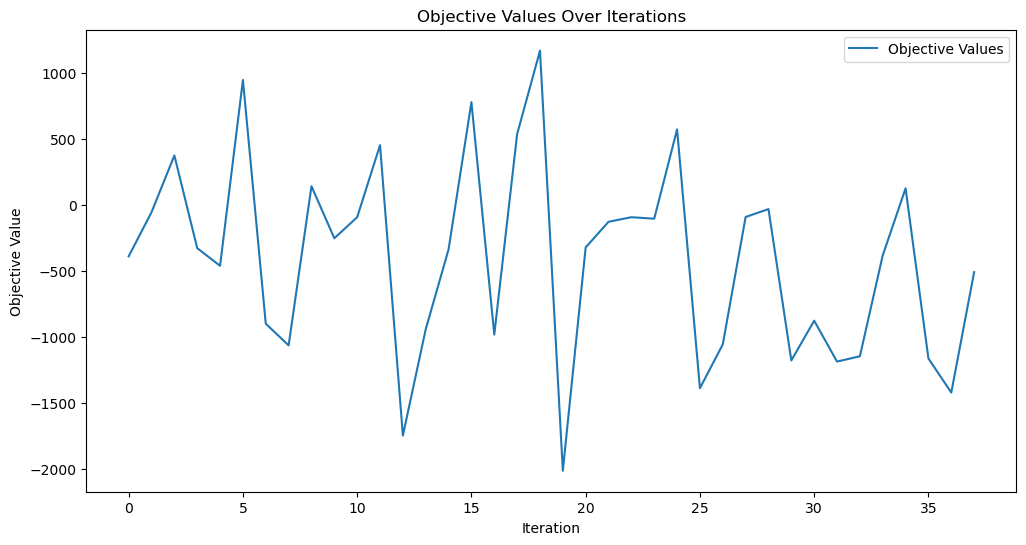

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(obj_values, label="Objective Values")
plt.xlabel("Iteration")
plt.ylabel("Objective Value")
plt.title("Objective Values Over Iterations")
plt.legend()
plt.show()